# Lightning Run Analysis (CLI Workflow)

Analyzes training results produced by `closure-train fit`.

`RunLoader` reconstructs the model, data, and test dataset from a
Lightning `version_*` directory, and provides one-liner access to
training history, evaluation metrics, and visualization.

## 1) Setup &amp; load run

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from closure import RunLoader

PROJECT_ROOT = Path('/volume1/scratch/georgem/closure')
os.chdir(PROJECT_ROOT)

LOG_ROOT = PROJECT_ROOT / 'models/Lightning/Harris/Le/lightning_logs'

# Pick the latest version directory
versions = sorted([p for p in LOG_ROOT.glob('version_*') if p.is_dir()])
if not versions:
    raise RuntimeError('No version_* folders found. Run training first.')
latest = versions[-1]
print('Loading:', latest)

run = RunLoader.from_version_dir(latest)
run

Loading: /volume1/scratch/georgem/closure/models/Lightning/Harris/Le/lightning_logs/version_0


read_data: prior to appending outshape = (512, 150, 1)
Output shape (3, 10, 512, 150, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (3, 10, 512, 150)
read_data: prior to appending outshape = (512, 150, 1)
Output shape (3, 6, 512, 150, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (3, 6, 512, 150)


RunLoader(version_0, targets=['Pxx_e', 'Pyy_e', 'Pzz_e', 'Pxy_e', 'Pxz_e', 'Pyz_e'], n_test_samples=3, model=ClosureLitModule)

## 2) CLI commands (for reference)

```bash
# Quick test run (3 epochs)
closure-train fit --config configs/legacy_harris_4lrs_es500.yaml \
    --trainer.devices=1 --trainer.strategy=auto --data.num_workers=2 --trainer.max_epochs=3

# Full training
PYTHONUNBUFFERED=1 closure-train fit --config configs/legacy_harris_4lrs_es500.yaml \
    --trainer.devices=1 --trainer.strategy=auto --data.num_workers=2 \
    2>&1 | tee models/Lightning/Harris/Le/train_full_$(date +%F_%H-%M-%S).log
```

## 3) Inspect runtime config

Access the full config dict via `run.config`.

In [2]:
for section in ('trainer', 'data'):
    print(f'\n[{section}]')
    for k, v in run.config.get(section, {}).items():
        if not isinstance(v, (dict, list)):
            print(f'  {k}: {v}')

print('\n[model.network]')
net_cfg = run.config.get('model', {}).get('network', {})
print(f'  class_path: {net_cfg.get("class_path")}')
print(f'  init_args:  {net_cfg.get("init_args", {})}')


[trainer]
  accelerator: auto
  strategy: auto
  devices: 1
  num_nodes: 1
  precision: None
  fast_dev_run: False
  max_epochs: 500
  min_epochs: None
  max_steps: -1
  min_steps: None
  max_time: None
  limit_train_batches: None
  limit_val_batches: None
  limit_test_batches: None
  limit_predict_batches: None
  overfit_batches: 0.0
  val_check_interval: None
  check_val_every_n_epoch: 1
  num_sanity_val_steps: None
  log_every_n_steps: None
  enable_checkpointing: None
  enable_progress_bar: None
  enable_model_summary: None
  accumulate_grad_batches: 1
  gradient_clip_val: None
  gradient_clip_algorithm: None
  deterministic: None
  benchmark: None
  inference_mode: True
  use_distributed_sampler: True
  profiler: None
  detect_anomaly: False
  barebones: False
  plugins: None
  sync_batchnorm: False
  reload_dataloaders_every_n_epochs: 0
  default_root_dir: ./models/Lightning/Harris/Le
  enable_autolog_hparams: True
  model_registry: None

[data]
  data_folder: ecsim/Harris/Le/
 

## 4) Training history &amp; loss curves

,epoch,train_loss,val_loss,lr-Adam
492,492.0,0.021964,0.011180,0.00001
493,493.0,0.023234,0.011208,0.00001
494,494.0,0.023822,0.012292,0.00001
495,495.0,0.024567,0.010912,0.00001
496,496.0,0.021975,0.011770,0.00001
497,497.0,0.023252,0.012537,0.00001
498,498.0,0.023299,0.011291,0.00001
499,499.0,0.021580,0.011423,0.00001


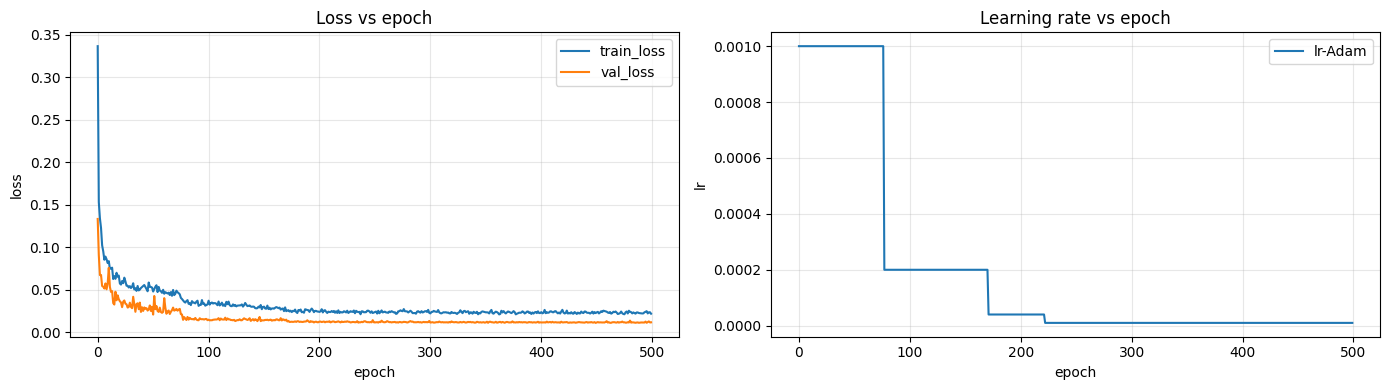

In [3]:
display(run.history().tail(8))
run.plot_history()

## 5) Best &amp; final epoch

In [4]:
run.best_epoch()

{'best_epoch': 449,
 'best_val_loss': 0.0107871061190962,
 'final_epoch': 499,
 'final_train_loss': 0.021580159664154,
 'final_val_loss': 0.0114227132871747}

## 6) Compare multiple Lightning versions

,version,path,best_val_loss,best_epoch
0,version_0,/volume1/scratch/georgem/closure/models/Lightn...,0.010787,449


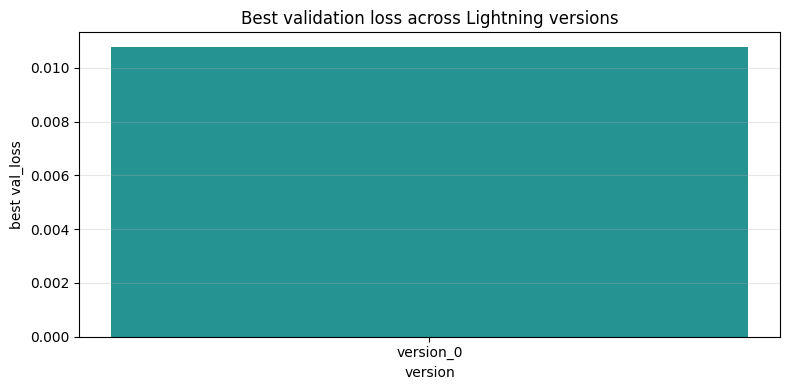

In [5]:
summary_df = RunLoader.compare_versions(LOG_ROOT)
display(summary_df)

if not summary_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(summary_df['version'], summary_df['best_val_loss'], color='teal', alpha=0.85)
    plt.title('Best validation loss across Lightning versions')
    plt.xlabel('version'); plt.ylabel('best val_loss')
    plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 7) Per-channel regression metrics

,channel_index,channel,mse,rmse,mae,r2,pearson_r,mean_abs_ground_truth,nrmse
1,1,Pyy_e,0.008040,0.089668,0.058517,0.993676,0.997163,0.945237,0.094864
2,2,Pzz_e,0.007338,0.085661,0.053737,0.993342,0.996987,0.884642,0.096831
0,0,Pxx_e,0.011314,0.106369,0.064303,0.989560,0.995538,0.865801,0.122856
5,5,Pyz_e,0.028347,0.168364,0.084216,0.979564,0.990839,0.424278,0.396826
4,4,Pxz_e,0.020345,0.142637,0.089145,0.978750,0.989459,0.554017,0.257459
3,3,Pxy_e,0.040296,0.200738,0.120261,0.969571,0.984878,0.570792,0.351683


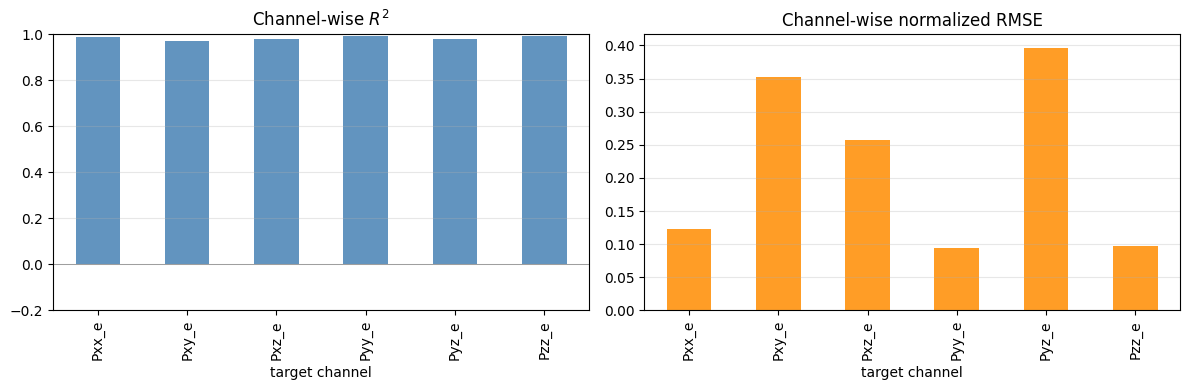

In [6]:
metrics_df = run.metrics()
display(metrics_df.sort_values('r2', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms = metrics_df.set_index('channel').sort_index()

ms['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

ms['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')
plt.tight_layout(); plt.show()

## 8) Predicted vs ground-truth images

Diagonal pressures (e.g. $P_{xx}$) use a sequential colormap.
Off-diagonal pressures ($P_{xy}$, etc.) are signed → diverging colormap.

invfunc = <ufunc 'exp'>


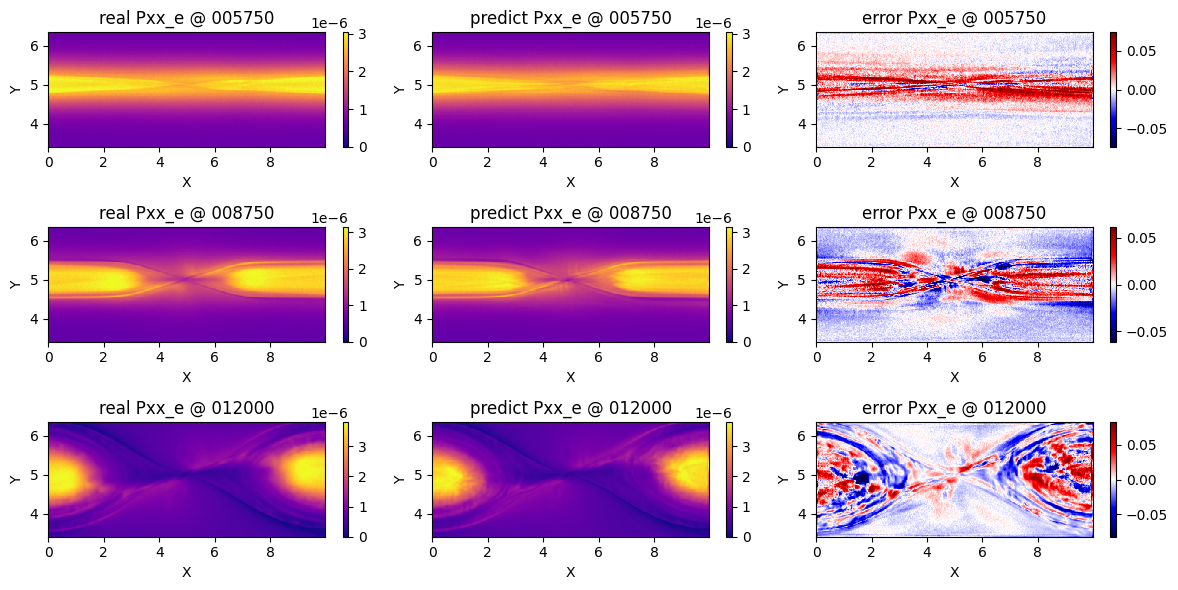

In [7]:
# Diagonal pressure
run.plot('Pxx_e', robust_quantile=0.995, error_mode='relative',
         signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

invfunc = <ufunc 'sinh'>


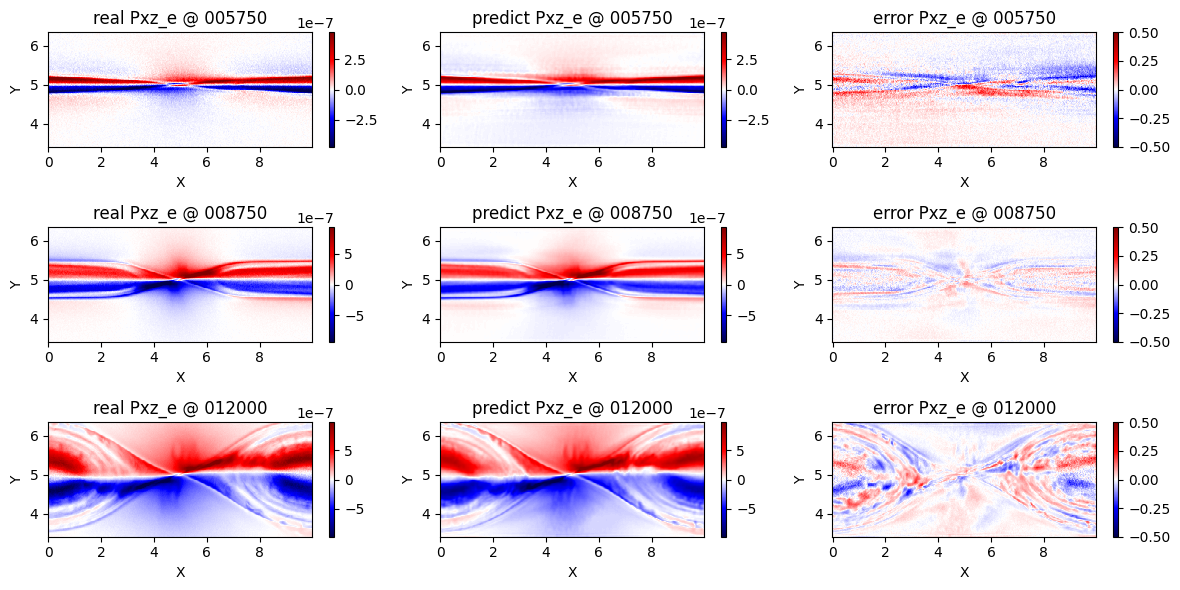

In [8]:
# Off-diagonal pressure (signed → diverging colormap)
offdiag = 'Pxz_e' if 'Pxz_e' in run.dataset.request_targets else run.dataset.request_targets[0]
run.plot(offdiag, robust_quantile=0.995, error_mode='symmetric_percent',
         error_limit=0.5, signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

## 9) Predicted vs true scatter

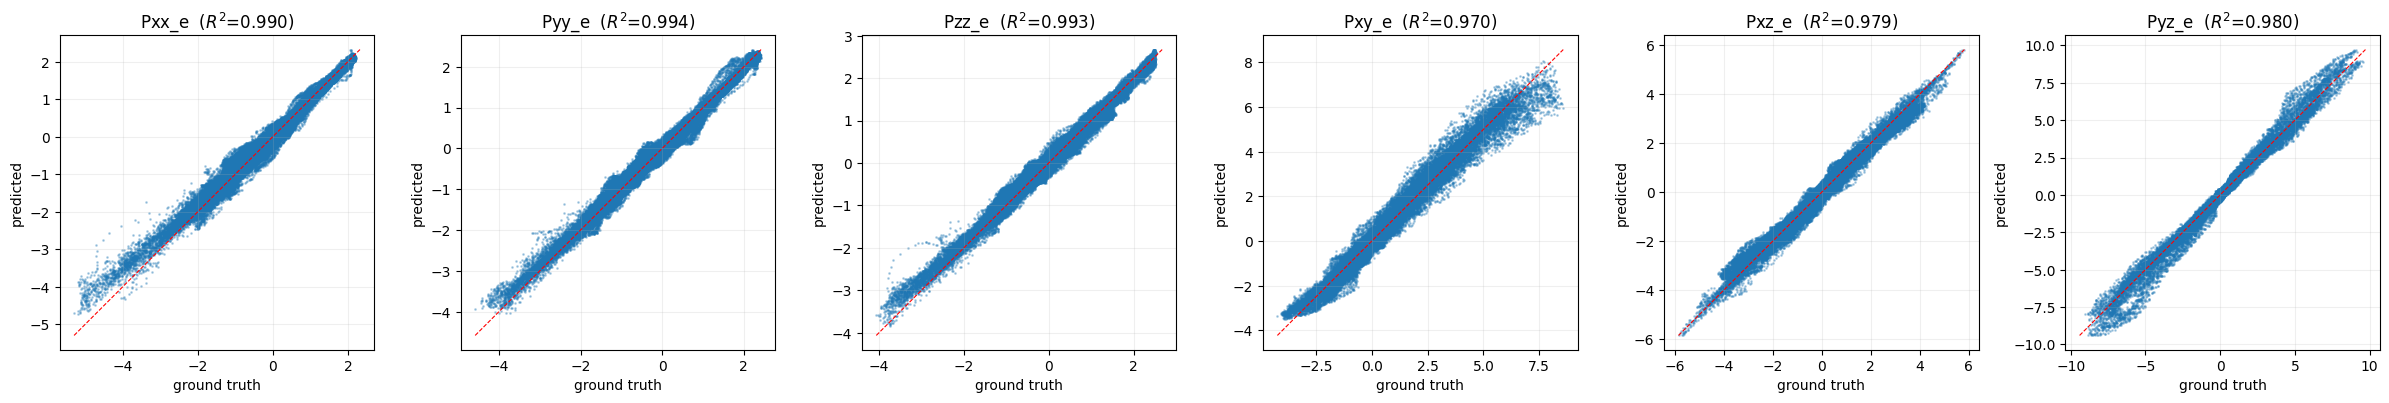

In [9]:
gt, pred = run.predict()
channels = run.dataset.request_targets
n_ch = len(channels)

fig, axes = plt.subplots(1, n_ch, figsize=(4 * n_ch, 4), squeeze=False)
for idx, ch_name in enumerate(channels):
    ax = axes[0, idx]
    y, yhat = gt[:, idx].ravel(), pred[:, idx].ravel()
    ax.scatter(y, yhat, s=1, alpha=0.3)
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    ax.plot(lims, lims, 'r--', linewidth=0.8)
    ax.set_xlabel('ground truth'); ax.set_ylabel('predicted')
    r2 = metrics_df.loc[metrics_df.channel == ch_name, 'r2'].values[0]
    ax.set_title(f'{ch_name}  ($R^2$={r2:.3f})')
    ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()